# **Interactive Image Classification on CIFAR-10 using Convolutional Neural Networks**

#### The code presents an end-to-end implementation of image classification using a convolutional neural network (CNN) on the CIFAR-10 dataset.The centerpiece of the code is the CNN architecture. The network structure begins with three convolutional layers, each followed by a max-pooling layer. These layers are pivotal in extracting patterns and features from the input images. After the convolutional blocks, the output is flattened, turning it into a 1D array, and passed through a dense layer.

###Step 1: Import the necessary libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
from tensorflow.keras.datasets import cifar10

###Step 2: Load and preprocess the cifar10 dataset

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 16s 0us/step


In [4]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


###Step 3: Define a complex convolutional network architecture

In [5]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])


c:\Workspace\MyProjects\DeepLearning\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


###Step 4: Compile the model

In [6]:
model.compile(optimizer=Adam(),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

###Step 5: Train the model

In [7]:
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2, batch_size=64)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.2597 - loss: 1.9666 - val_accuracy: 0.4891 - val_loss: 1.4112
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.4828 - loss: 1.4291 - val_accuracy: 0.5482 - val_loss: 1.2432
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.5391 - loss: 1.2837 - val_accuracy: 0.5980 - val_loss: 1.1245
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.5825 - loss: 1.1707 - val_accuracy: 0.6301 - val_loss: 1.0505
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.6194 - loss: 1.0723 - val_accuracy: 0.6276 - val_loss: 1.0444
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.6414 - loss: 1.0188 - val_accuracy: 0.6652 - val_loss: 0.9518
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.6661 - loss: 0.9499 - val_accuracy: 0.6798 - val_loss: 0.9268
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.6842 - loss: 0.9018 - 

###Step 6: Evaluate the model on test set

In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("\nTest accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6760 - loss: 0.9510

Test accuracy: 0.6728000044822693


###Step 7: Plot training history

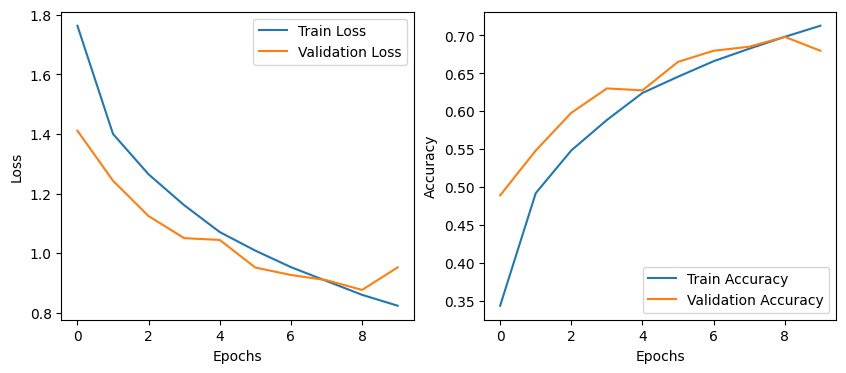

In [9]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

###Step 8: Make predictions interactively

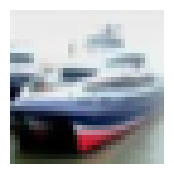

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Predicted Label: 8


In [12]:
while True:
    sample_idx = int(input("\nEnter the index of the test sample (0-9999), -1 to exit: "))
    if sample_idx == -1:
        break

    if 0 <= sample_idx <= 9999:
        sample_image = x_test[sample_idx]
        plt.imshow(sample_image)
        # set size of the image
        plt.gcf().set_size_inches(2, 2)
        plt.axis('off')
        plt.show()

        predicted_probs = model.predict(np.expand_dims(sample_image, axis=0))
        predicted_label = np.argmax(predicted_probs)
        print("Predicted Label:", predicted_label)
    else:
        print("Invalid index. Please enter a valid index between 0 and 9999.")

###Conclusion: In essence, this code offers a comprehensive process, starting from loading and preprocessing data, constructing and training a CNN, visualizing training results, and making interactive predictions on the CIFAR-10 dataset.